# xgboost
- Liad Mandil, 315096073
- Maxim Prokopchuk, 337875397

## Imports

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.model_selection import train_test_split , cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn import tree
from sklearn.model_selection import train_test_split , cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc

-------------------

## Load Data

In [62]:
spaceship_data = pd.read_csv('final_data.csv')

## split to x and y

In [63]:
y = spaceship_data["Transported"].astype(int)
x = spaceship_data.drop(columns=["Transported"])

## Train-Test Split

In [64]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [65]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## בדיקת ערכי ההייפר פרמטרים

#### Base

In [66]:
xgb_base = XGBClassifier(
    random_state=42,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
)

fold_scores = cross_val_score(
    xgb_base,
    x_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("XGBoost Baseline")
print("Fold accuracies (%):", np.round(100 * fold_scores, 2))
print(f"Mean CV accuracy: {100*fold_scores.mean():.2f}% | Std: {100*fold_scores.std():.2f}%")


XGBoost Baseline
Fold accuracies (%): [79.78 80.07 81.01 80.79 80.2 ]
Mean CV accuracy: 80.37% | Std: 0.46%


#### max_depth

In [67]:
results_depth = []
best_depth = None
best_depth_score = -1

depth_list = [2, 3, 4, 5, 6, 7]

for depth in depth_list:

    xgb = XGBClassifier(
        random_state=42,
        n_estimators=300,    
        max_depth=depth,
        learning_rate=0.1,
        subsample=1.0,
        colsample_bytree=1.0,
        eval_metric="logloss",
        n_jobs=-1
    )

    fold_scores = cross_val_score(
        xgb,
        x_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    mean_score = fold_scores.mean()

    results_depth.append({
        "max_depth": depth,
        "cv_mean": mean_score,
        "cv_std": fold_scores.std()
    })

    if mean_score > best_depth_score:
        best_depth_score = mean_score
        best_depth = depth


In [68]:
results_depth_df = pd.DataFrame(results_depth).sort_values("cv_mean", ascending=False)
display(results_depth_df.round(4))

print("Best depth:", best_depth)

,max_depth,cv_mean,cv_std
3,5,0.8043,0.0038
2,4,0.8037,0.0046
1,3,0.8033,0.0074
4,6,0.8017,0.0038
0,2,0.8006,0.0077
5,7,0.8002,0.0030


Best depth: 5


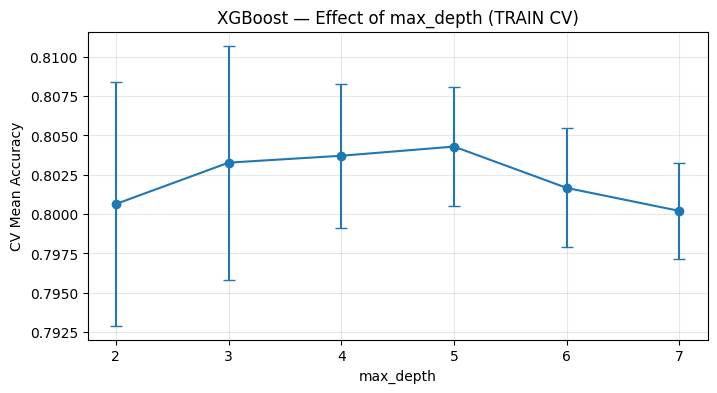

In [69]:
tmp = results_depth_df.sort_values("max_depth")

plt.figure(figsize=(8,4))
plt.errorbar(
    tmp["max_depth"],
    tmp["cv_mean"],
    yerr=tmp["cv_std"],
    fmt="o-",
    capsize=4
)

plt.title("XGBoost — Effect of max_depth (TRAIN CV)")
plt.xlabel("max_depth")
plt.ylabel("CV Mean Accuracy")
plt.grid(alpha=0.3)
plt.show()


#### n_estimators

In [70]:
results_trees = []
best_trees = None
best_trees_score = -1

n_list = range(100, 1001, 50)

for n in n_list:

    xgb = XGBClassifier(
        random_state=42,
        n_estimators=n,
        max_depth=best_depth,
        learning_rate=0.1,
    
    )

    fold_scores = cross_val_score(
        xgb,
        x_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    mean_score = fold_scores.mean()

    results_trees.append({
        "n_estimators": n,
        "cv_mean": mean_score,
        "cv_std": fold_scores.std()
    })

    if mean_score > best_trees_score:
        best_trees_score = mean_score
        best_trees = n


In [71]:
results_trees_df = pd.DataFrame(results_trees).sort_values("cv_mean", ascending=False)
display(results_trees_df.round(4).head(5))

print("Best n_estimators:", best_trees)

,n_estimators,cv_mean,cv_std
1,150,0.8056,0.0046
2,200,0.8055,0.0026
3,250,0.8047,0.0020
4,300,0.8043,0.0038
10,600,0.8033,0.0046


Best n_estimators: 150


#### learning_rate

In [72]:
results_lr = []
best_lr = None
best_lr_score = -1

lr_list = [0.01, 0.03, 0.1, 0.2]

for lr in lr_list:

    xgb = XGBClassifier(
        random_state=42,
        n_estimators=best_trees,
        max_depth=best_depth,
        learning_rate=lr,
    )

    fold_scores = cross_val_score(
        xgb,
        x_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    mean_score = fold_scores.mean()

    results_lr.append({
        "learning_rate": lr,
        "cv_mean": mean_score,
        "cv_std": fold_scores.std()
    })

    if mean_score > best_lr_score:
        best_lr_score = mean_score
        best_lr = lr




In [73]:
results_lr_df = pd.DataFrame(results_lr).sort_values("cv_mean", ascending=False)
display(results_lr_df.round(4))

print("Best learning_rate:", best_lr)

,learning_rate,cv_mean,cv_std
2,0.10,0.8056,0.0046
3,0.20,0.8049,0.0044
1,0.03,0.7974,0.0076
0,0.01,0.7863,0.0032


Best learning_rate: 0.1


#### best model

In [74]:
best_params_xgb = {
    "max_depth": best_depth,
    "n_estimators": best_trees,
    "learning_rate": best_lr
}

print("Best XGB params:", best_params_xgb)

best_XGB = XGBClassifier(
    random_state=42,
    max_depth=best_depth,
    n_estimators=best_trees,
    learning_rate=best_lr,
)

best_XGB.fit(x_train, y_train)


Best XGB params: {'max_depth': 5, 'n_estimators': 150, 'learning_rate': 0.1}


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=150,
              n_jobs=None, num_parallel_tree=None, ...)

In [75]:
best_xgb_params = {
    "max_depth": 5,
    "n_estimators": 150,
    "learning_rate": 0.1
}

xgb_params_df = pd.DataFrame(
    list(best_xgb_params.items()),
    columns=["Parameter", "Value"]
)

display(xgb_params_df)

,Parameter,Value
0,max_depth,5.0
1,n_estimators,150.0
2,learning_rate,0.1


## Results

In [76]:
y_pred_train = best_XGB.predict(x_train)
train_acc = accuracy_score(y_train, y_pred_train)
print("="*40)
print("BEST XGB — TRAIN SET PERFORMANCE")
print("="*40)
print(f"Accuracy : {train_acc*100:.2f}%")
print("="*40)

BEST XGB — TRAIN SET PERFORMANCE
Accuracy : 87.64%


<Figure size 500x500 with 0 Axes>

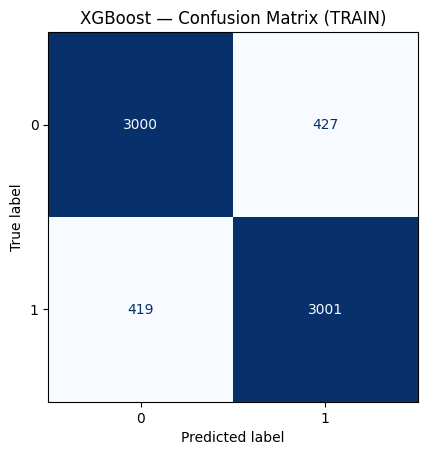

In [77]:
plt.figure(figsize=(5,5))
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_pred_train,
    cmap="Blues",
    colorbar=False
)

plt.title("XGBoost — Confusion Matrix (TRAIN)")
plt.show()

In [78]:
acc = accuracy_score(y_train, y_pred_train)
prec = precision_score(y_train, y_pred_train)
rec = recall_score(y_train, y_pred_train)
f1 = f1_score(y_train, y_pred_train)

metrics_df = pd.DataFrame([{
    "model": "XGBoost",
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1_score": f1
}])

display(metrics_df.round(4))

print("\nClassification Report (TRAIN):")
print(classification_report(y_train, y_pred_train))

,model,accuracy,precision,recall,f1_score
0,XGBoost,0.8764,0.8754,0.8775,0.8765



Classification Report (TRAIN):
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      3427
           1       0.88      0.88      0.88      3420

    accuracy                           0.88      6847
   macro avg       0.88      0.88      0.88      6847
weighted avg       0.88      0.88      0.88      6847



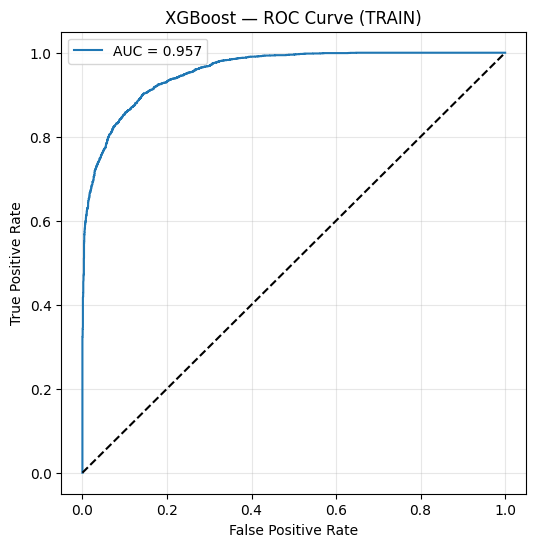

In [79]:
y_prob_train = best_XGB.predict_proba(x_train)[:, 1]

fpr, tpr, _ = roc_curve(y_train, y_prob_train)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost — ROC Curve (TRAIN)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

,feature,importance
15,HomePlanet_0.0,0.212128
8,TotalSpend,0.170108
0,CryoSleep,0.162630
16,HomePlanet_1.0,0.045105
4,FoodCourt,0.042841
5,ShoppingMall,0.042487
13,RoomSide,0.038339
6,Spa,0.035864
11,Deck,0.030750
7,VRDeck,0.029991


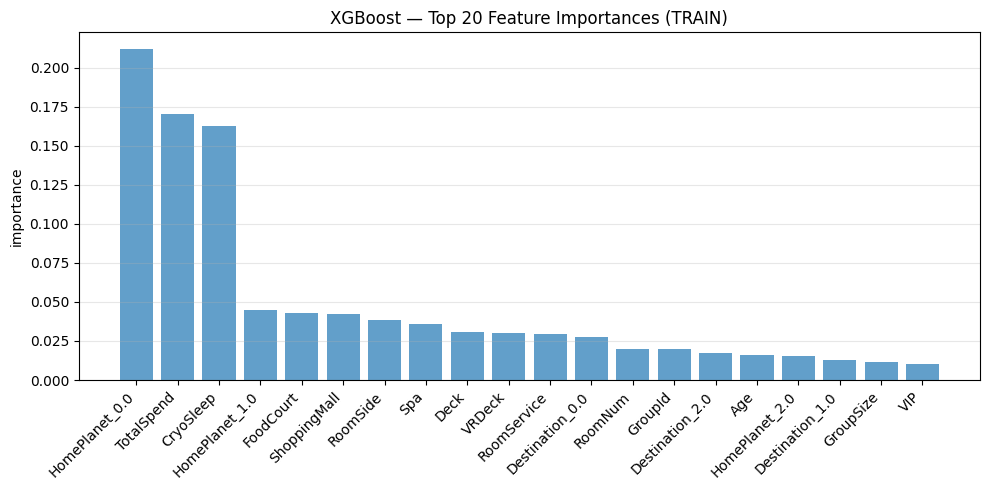

In [80]:
feature_names = x_train.columns.tolist()
importances = best_XGB.feature_importances_

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(fi_df.head(20))

x = np.arange(len(fi_df.head(20)))
plt.figure(figsize=(10,5))
plt.bar(x, fi_df.head(20)["importance"], alpha=0.7)
plt.xticks(x, fi_df.head(20)["feature"], rotation=45, ha="right")
plt.title("XGBoost — Top 20 Feature Importances (TRAIN)")
plt.ylabel("importance")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
